In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_csv("customer_churn_data.csv")
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.2+ KB


In [12]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [13]:
df.isnull().sum()

CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [14]:
df.isnull().sum().sort_values(ascending = False)

InternetService    297
CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

In [15]:
df['InternetService']

0      Fiber Optic
1      Fiber Optic
2      Fiber Optic
3              DSL
4              NaN
          ...     
995    Fiber Optic
996            NaN
997    Fiber Optic
998            NaN
999            NaN
Name: InternetService, Length: 1000, dtype: object

In [17]:
df['InternetService'] = df['InternetService'].fillna('None')

In [18]:
df.isnull().sum()

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [20]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
995    False
996    False
997    False
998    False
999    False
Length: 1000, dtype: bool

In [21]:
df.drop_duplicates(inplace= True)

In [22]:
df.duplicated().sum()

0

In [23]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [24]:
df.shape

(1000, 10)

In [25]:
df['Churn'] = df['Churn'].apply(lambda x : 1 if x == 'Yes' else 0)
df['Churn']

0      1
1      1
2      1
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: Churn, Length: 1000, dtype: int64

In [26]:
num_cols = df.select_dtypes(include= 'number')
num_cols

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges,Churn
0,1,49,4,88.35,353.40,1
1,2,43,0,36.67,0.00,1
2,3,51,2,63.79,127.58,1
3,4,60,8,102.34,818.72,1
4,5,42,32,69.01,2208.32,1
...,...,...,...,...,...,...
995,996,42,41,37.14,1522.74,1
996,997,62,9,80.93,728.37,1
997,998,51,15,111.72,1675.80,1
998,999,39,68,65.67,4465.56,1


<Axes: ylabel='Churn'>

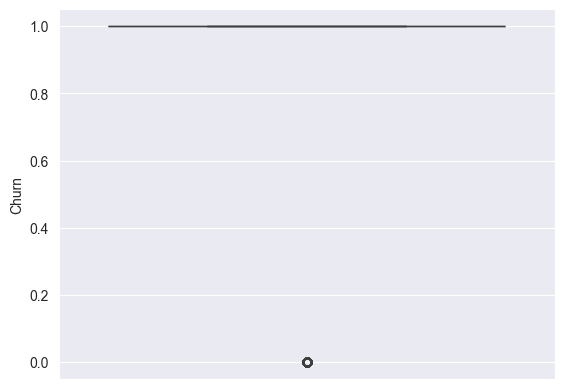

In [27]:
import matplotlib.pyplot as plt
sns.set_style('darkgrid')
sns.boxplot(df, y = 'Churn')

<Axes: ylabel='Age'>

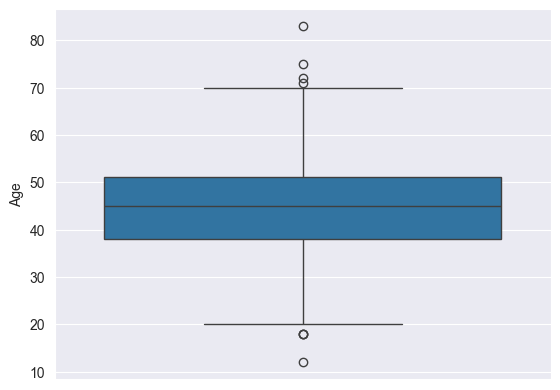

In [28]:
sns.boxplot(df, y = 'Age')

<Axes: ylabel='Tenure'>

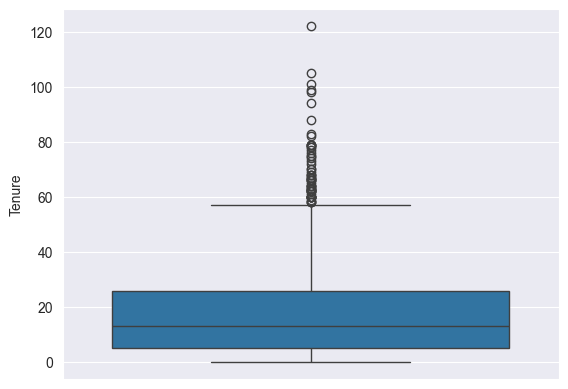

In [29]:
sns.boxplot(df, y = 'Tenure')

<Axes: ylabel='MonthlyCharges'>

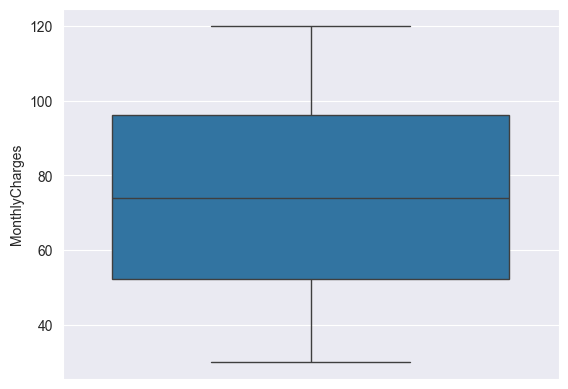

In [30]:
sns.boxplot(df , y ='MonthlyCharges')

<Axes: ylabel='TotalCharges'>

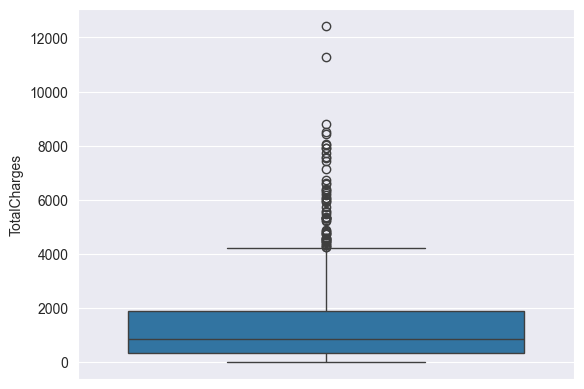

In [31]:
sns.boxplot(df, y = 'TotalCharges')

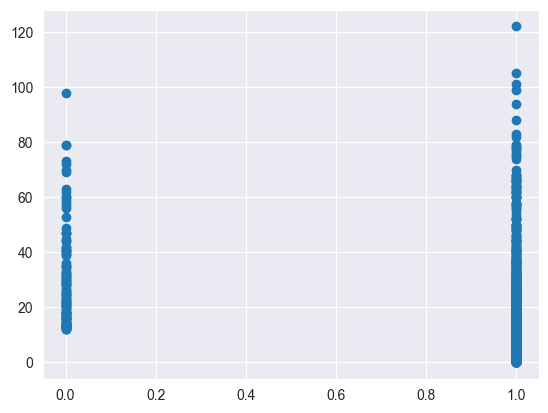

In [32]:
plt.scatter(df['Churn'], df['Tenure'])

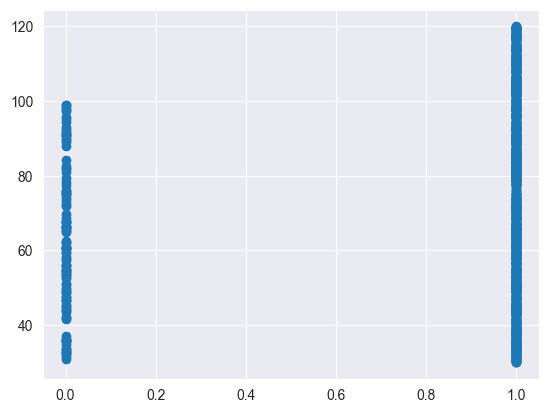

In [33]:
plt.scatter(df['Churn'], df['MonthlyCharges'])

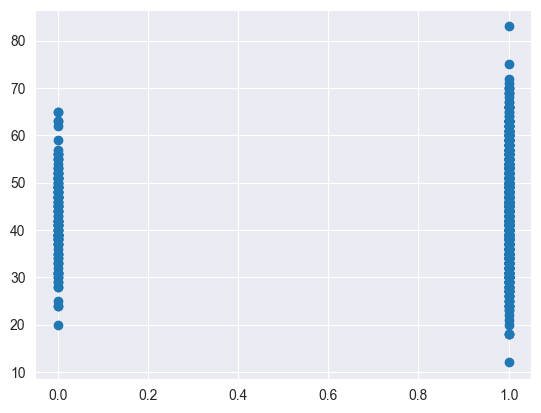

In [34]:
plt.scatter(df['Churn'], df['Age'])

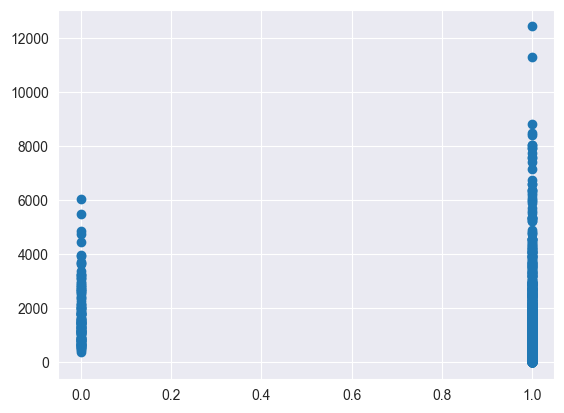

In [35]:
plt.scatter(df['Churn'], df['TotalCharges'])


<Axes: xlabel='Age', ylabel='Count'>

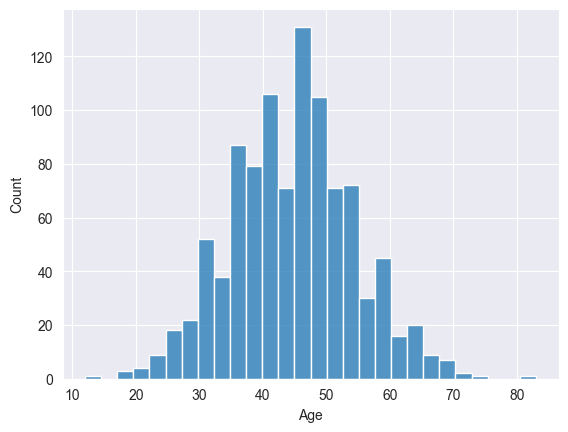

In [36]:
sns.histplot(df['Age'])

<Axes: xlabel='Tenure', ylabel='Count'>

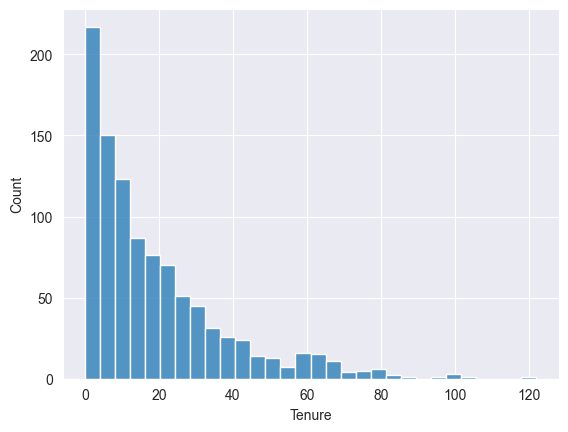

In [37]:
sns.histplot(df['Tenure'])

<Axes: xlabel='MonthlyCharges', ylabel='Count'>

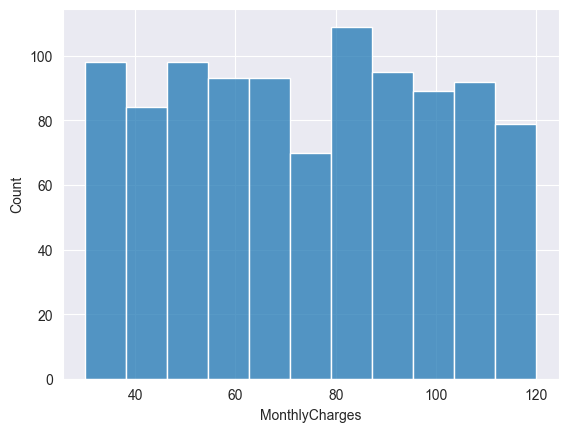

In [38]:
sns.histplot(df['MonthlyCharges'])

<Axes: xlabel='TotalCharges', ylabel='Count'>

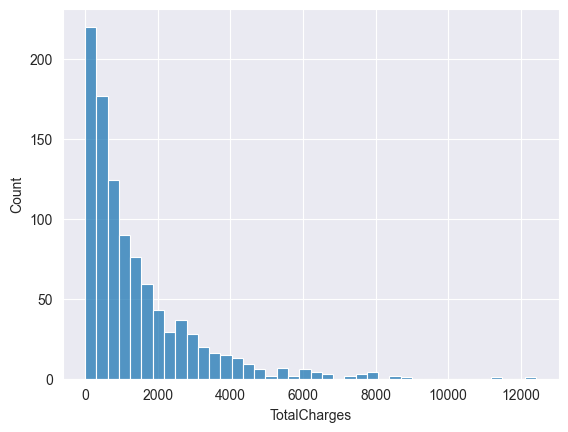

In [39]:
sns.histplot(df['TotalCharges'])

<Axes: xlabel='Churn', ylabel='Count'>

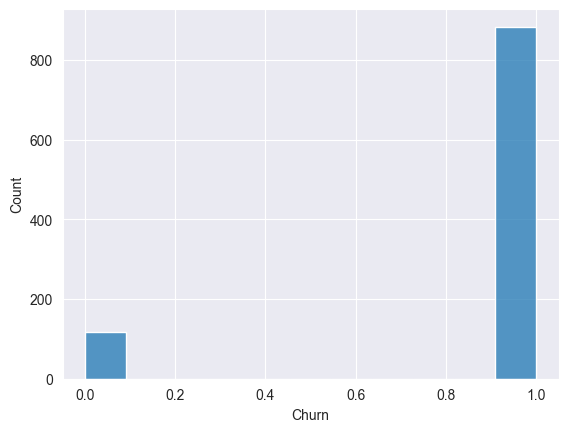

In [40]:
sns.histplot(df['Churn'])

In [41]:
df.columns


Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges',
       'ContractType', 'InternetService', 'TotalCharges', 'TechSupport',
       'Churn'],
      dtype='object')

In [42]:
df.drop(columns= ['CustomerID'], inplace= True)

In [43]:
df['Churn'].dtype

dtype('int64')

In [44]:
df['Churn'].value_counts()

Churn
1    883
0    117
Name: count, dtype: int64

In [45]:
corr = df.corr(numeric_only= True)
corr

,Age,Tenure,MonthlyCharges,TotalCharges,Churn
Age,1.000000,0.000472,0.006362,-0.001896,0.044115
Tenure,0.000472,1.000000,-0.014552,0.894868,-0.217675
MonthlyCharges,0.006362,-0.014552,1.000000,0.304893,0.167773
TotalCharges,-0.001896,0.894868,0.304893,1.000000,-0.101523
Churn,0.044115,-0.217675,0.167773,-0.101523,1.000000


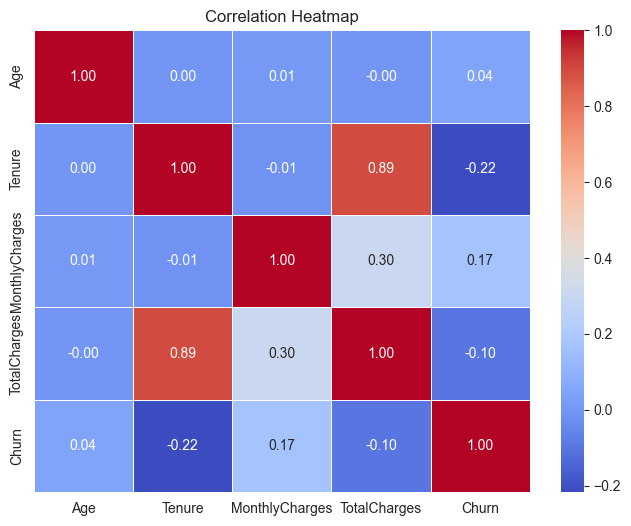

In [48]:
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Correlation Heatmap")
plt.show()

In [49]:
corr['Churn'].sort_values(ascending= False)

Churn             1.000000
MonthlyCharges    0.167773
Age               0.044115
TotalCharges     -0.101523
Tenure           -0.217675
Name: Churn, dtype: float64

<Axes: ylabel='TotalCharges'>

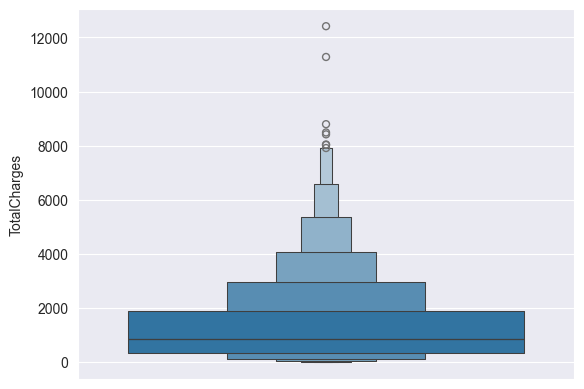

In [50]:
sns.boxenplot(df['TotalCharges'])

In [51]:
df['TotalCharges'].describe()

count     1000.000000
mean      1404.364060
std       1571.755048
min          0.000000
25%        345.217500
50%        872.870000
75%       1900.175000
max      12416.250000
Name: TotalCharges, dtype: float64

In [52]:
df.sort_values('TotalCharges', ascending= False).head(10)

,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
493,36,Female,105,118.25,Month-to-Month,DSL,12416.25,Yes,1
540,53,Male,99,113.93,Month-to-Month,None,11279.07,No,1
509,36,Female,75,117.28,One-Year,DSL,8796.00,No,1
233,38,Female,122,69.58,Month-to-Month,DSL,8488.76,No,1
440,48,Male,94,89.57,One-Year,Fiber Optic,8419.58,No,1
136,37,Female,82,98.11,Month-to-Month,Fiber Optic,8045.02,No,1
617,52,Male,68,118.05,Month-to-Month,Fiber Optic,8027.40,Yes,1
771,39,Male,67,118.12,Month-to-Month,Fiber Optic,7914.04,Yes,1
741,32,Male,78,101.44,Two-Year,None,7912.32,No,1
689,49,Male,68,113.74,Month-to-Month,DSL,7734.32,Yes,1


In [53]:
df.select_dtypes(include='object')

,Gender,ContractType,InternetService,TechSupport
0,Male,Month-to-Month,Fiber Optic,Yes
1,Male,Month-to-Month,Fiber Optic,Yes
2,Female,Month-to-Month,Fiber Optic,No
3,Female,One-Year,DSL,Yes
4,Male,Month-to-Month,None,No
...,...,...,...,...
995,Male,Month-to-Month,Fiber Optic,Yes
996,Male,Month-to-Month,None,No
997,Female,Month-to-Month,Fiber Optic,Yes
998,Male,One-Year,None,No


In [54]:
pd.get_dummies(df, drop_first= True)

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic,InternetService_None,TechSupport_Yes
0,49,4,88.35,353.40,1,True,False,False,True,False,True
1,43,0,36.67,0.00,1,True,False,False,True,False,True
2,51,2,63.79,127.58,1,False,False,False,True,False,False
3,60,8,102.34,818.72,1,False,True,False,False,False,True
4,42,32,69.01,2208.32,1,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
995,42,41,37.14,1522.74,1,True,False,False,True,False,True
996,62,9,80.93,728.37,1,True,False,False,False,True,False
997,51,15,111.72,1675.80,1,False,False,False,True,False,True
998,39,68,65.67,4465.56,1,True,True,False,False,True,False


In [55]:
df = pd.get_dummies(df, drop_first= True, dtype= int)

In [56]:
df.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Churn,Gender_Male,ContractType_One-Year,ContractType_Two-Year,InternetService_Fiber Optic,InternetService_None,TechSupport_Yes
0,49,4,88.35,353.40,1,1,0,0,1,0,1
1,43,0,36.67,0.00,1,1,0,0,1,0,1
2,51,2,63.79,127.58,1,0,0,0,1,0,0
3,60,8,102.34,818.72,1,0,1,0,0,0,1
4,42,32,69.01,2208.32,1,1,0,0,0,1,0


In [57]:
df.shape

(1000, 11)

In [58]:
X = df.drop(columns=['Churn'], axis =1 )
y = df['Churn']


In [59]:
X.shape, y.shape

((1000, 10), (1000,))

In [60]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train , y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [61]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape 

((800, 10), (200, 10), (800,), (200,))

In [62]:
from sklearn.preprocessing import StandardScaler
sclaer = StandardScaler()

In [63]:
X_train_scaled = sclaer.fit_transform(X_train)
X_test_scaled = sclaer.transform(X_test)


In [64]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()
log.fit(X_train_scaled, y_train)

LogisticRegression()

In [65]:
log_pred = log.predict(X_test_scaled)

In [68]:
log_pred[:5]

array([1, 1, 1, 1, 1])

In [69]:
y_test[:5]

521    1
737    1
740    1
660    1
411    1
Name: Churn, dtype: int64

In [70]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [71]:
accuracy_score(y_test, log_pred)

0.955

In [72]:
confusion_matrix(y_test, log_pred)

array([[ 17,   6],
       [  3, 174]])

In [73]:
classification_report(y_test, log_pred)

'              precision    recall  f1-score   support\n\n           0       0.85      0.74      0.79        23\n           1       0.97      0.98      0.97       177\n\n    accuracy                           0.95       200\n   macro avg       0.91      0.86      0.88       200\nweighted avg       0.95      0.95      0.95       200\n'

In [77]:
from sklearn.metrics import roc_auc_score

y_prob = log.predict_proba(X_test_scaled)[:, 1]  # probability of class 1
auc = roc_auc_score(y_test, y_prob)

In [78]:
auc

0.9845246868091377

In [80]:
print(log.classes_)

[0 1]


In [81]:
print(log.predict_log_proba(X_test)[:5])

[[-inf   0.]
 [-inf   0.]
 [-inf   0.]
 [-inf   0.]
 [-inf   0.]]


In [82]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()

In [83]:
dt.fit(X_train, y_train)

DecisionTreeClassifier()

In [84]:
dt_pred = dt.predict(X_test)

In [85]:
dt_pred[:5]

array([1, 1, 1, 1, 1])

In [86]:
y_test[:5]

521    1
737    1
740    1
660    1
411    1
Name: Churn, dtype: int64

In [87]:
accuracy_score(y_test, dt_pred)

0.995

In [88]:
confusion_matrix(y_test, dt_pred)

array([[ 23,   0],
       [  1, 176]])

In [89]:
classification_report(y_test, dt_pred)

'              precision    recall  f1-score   support\n\n           0       0.96      1.00      0.98        23\n           1       1.00      0.99      1.00       177\n\n    accuracy                           0.99       200\n   macro avg       0.98      1.00      0.99       200\nweighted avg       1.00      0.99      1.00       200\n'

In [90]:
dt.score(X_train , y_train)

1.0

In [91]:
dt.score(X_test, y_test)

0.995

In [92]:
from sklearn.metrics import roc_auc_score

dt_prob = dt.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test,dt_prob))

ROC-AUC: 0.9971751412429379


In [93]:
dt.get_depth()

5

In [94]:
dt.get_n_leaves()

7

In [95]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [96]:
accuracy_score(y_test, rf_pred)

1.0

In [97]:
classification_report(y_test, rf_pred)

'              precision    recall  f1-score   support\n\n           0       1.00      1.00      1.00        23\n           1       1.00      1.00      1.00       177\n\n    accuracy                           1.00       200\n   macro avg       1.00      1.00      1.00       200\nweighted avg       1.00      1.00      1.00       200\n'

In [98]:
confusion_matrix(y_test, rf_pred)

array([[ 23,   0],
       [  0, 177]])

In [99]:
rf.score(X_test, y_test)

1.0

In [100]:
import pandas as pd 

importance_df = pd.DataFrame({
    'Feature' : X.columns,
    'Importance' : rf.feature_importances_
})

In [101]:
importance_df.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
1,Tenure,0.183255
5,ContractType_One-Year,0.174667
9,TechSupport_Yes,0.167355
2,MonthlyCharges,0.147185
6,ContractType_Two-Year,0.136192
3,TotalCharges,0.107250
0,Age,0.037867
8,InternetService_None,0.023521
7,InternetService_Fiber Optic,0.012664
4,Gender_Male,0.010045


In [102]:
df.corr(numeric_only=True)['Churn'].sort_values(ascending=False)


Churn                          1.000000
InternetService_None           0.236599
MonthlyCharges                 0.167773
Age                            0.044115
Gender_Male                    0.031539
TotalCharges                  -0.101523
InternetService_Fiber Optic   -0.145011
ContractType_Two-Year         -0.175782
Tenure                        -0.217675
ContractType_One-Year         -0.255231
TechSupport_Yes               -0.359667
Name: Churn, dtype: float64

In [103]:
rf_prob = rf.predict_proba(X_test)[:,1]


In [104]:
auc = roc_auc_score(y_test, rf_prob)

In [105]:
auc

1.0

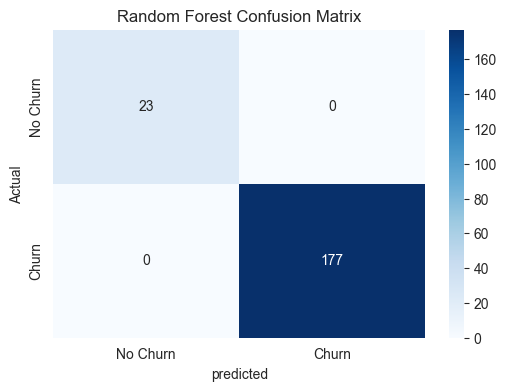

In [109]:
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6,4))
sns.heatmap(
    cm, 
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Churn', 'Churn'],
    yticklabels=['No Churn', 'Churn']
)
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

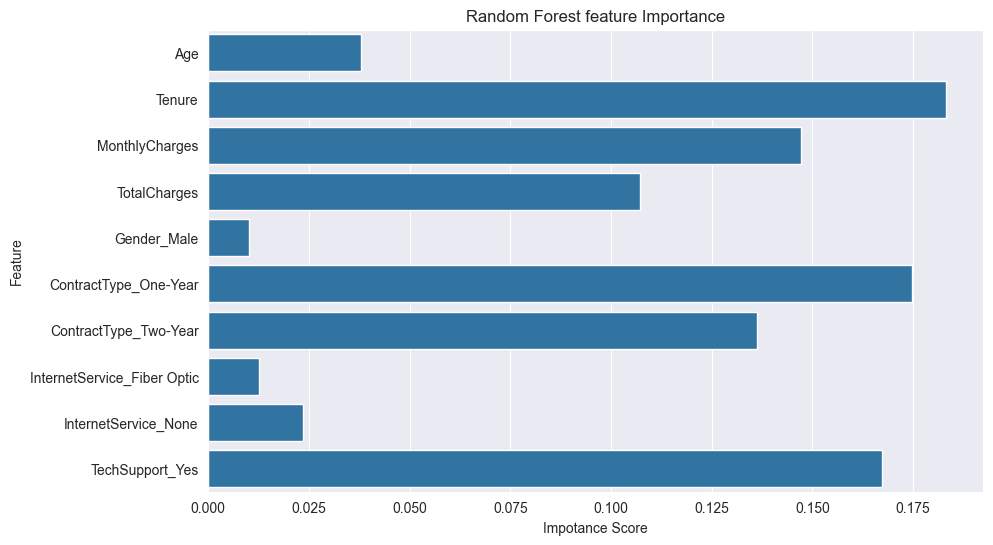

In [110]:
plt.figure(figsize=(10,6))
sns.barplot(
    data=importance_df,
    x = 'Importance', 
    y='Feature'
)

plt.title('Random Forest feature Importance')
plt.xlabel('Impotance Score')
plt.ylabel('Feature')
plt.show()

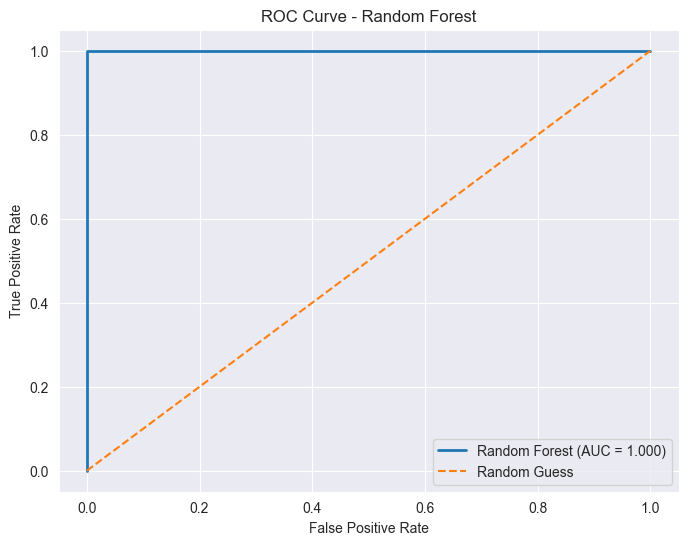

ROC-AUC Score: 1.0


In [111]:
from sklearn.metrics import roc_curve
rf_prob = rf.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test, rf_prob)

# ROC Curve points
fpr, tpr, thresholds = roc_curve(y_test, rf_prob)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'Random Forest (AUC = {rf_auc:.3f})'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc='lower right')

plt.show()

print("ROC-AUC Score:", rf_auc)

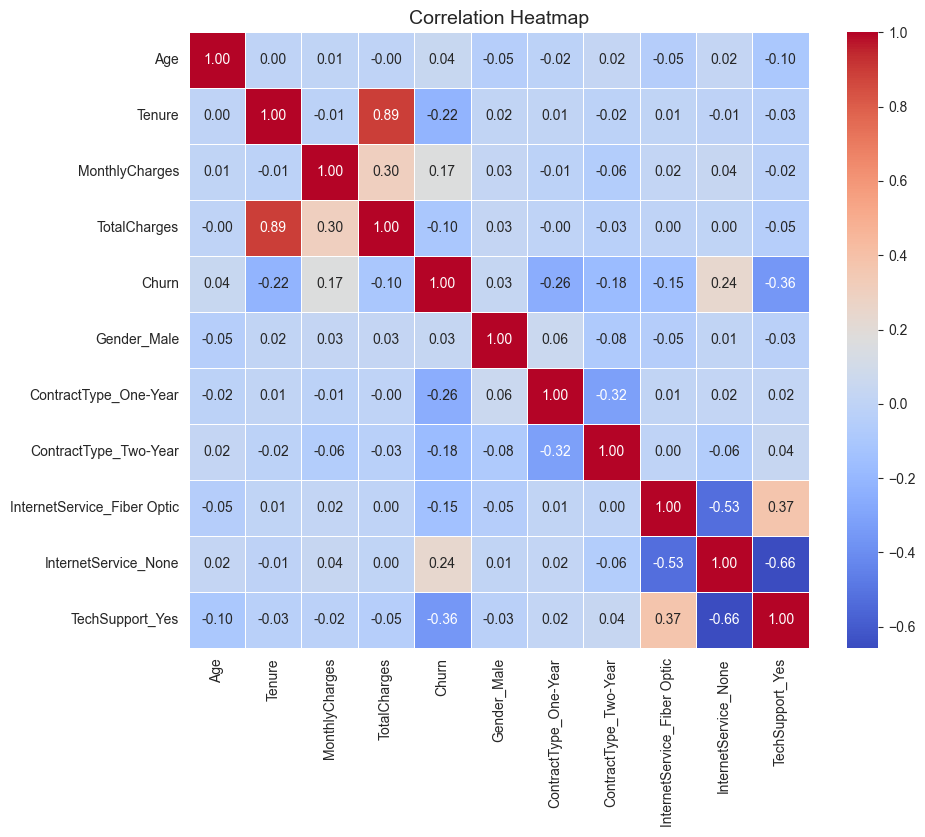

In [112]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()

In [113]:
results = pd.DataFrame({
    'Model' : ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy' : [0.955, 0.995, 1.000],
    'Precision' : [0.95, 0.99, 1.00],
    'Recall' : [0.95, 0.99, 1.00],
    'F1-Score' : [0.95, 0.99, 1.00],
    'ROC-AUC' : [0.985, 0.997, 1.000]
})

results

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.955,0.95,0.95,0.95,0.985
1,Decision Tree,0.995,0.99,0.99,0.99,0.997
2,Random Forest,1.000,1.00,1.00,1.00,1.000


In [114]:
import joblib

In [115]:
joblib.dump(sclaer, "sclaer.pkl")
joblib.dump(rf, "Customer_Churn_model.pkl")

['Customer_Churn_model.pkl']

In [116]:
import os 
os.listdir

<function posix.listdir(path=None)>

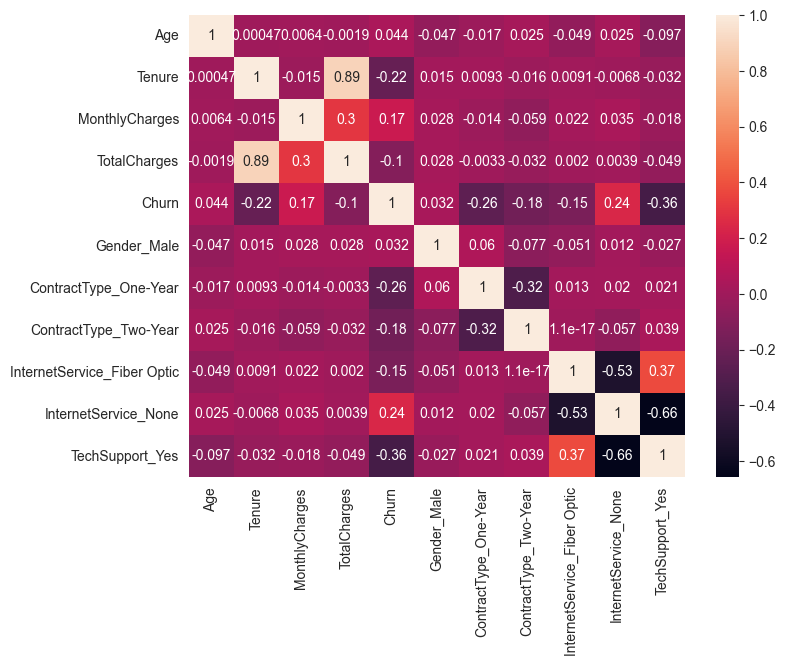

In [117]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)

plt.savefig("correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [118]:
feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

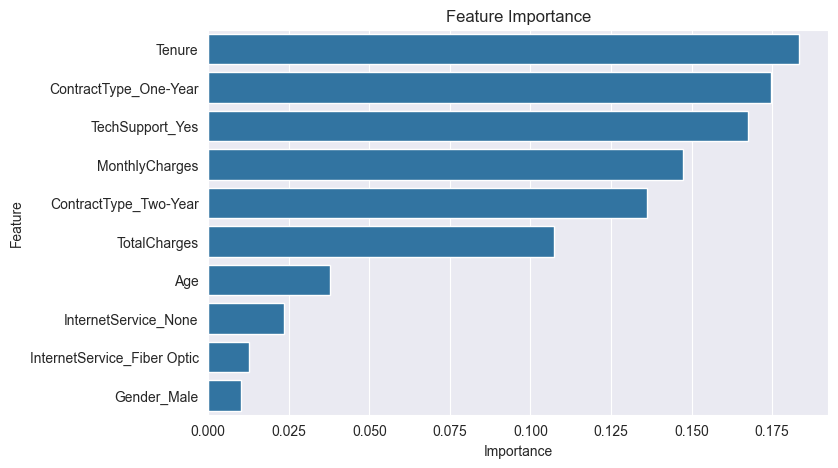

In [119]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance_df,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")

plt.savefig("feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

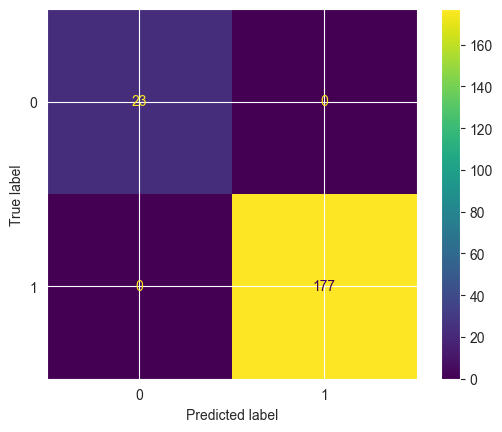

In [120]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    rf,
    X_test,
    y_test
)

plt.savefig("confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

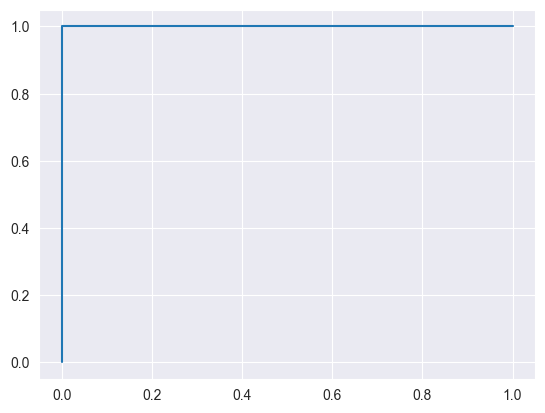

In [122]:

plt.plot(fpr, tpr)

plt.savefig("roc_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [123]:
import os

os.listdir()

['confusion_matrix.png',
 'sclaer.pkl',
 'Customer_Churn_model.pkl',
 'customer_churn_data.csv',
 'feature_importance.png',
 'correlation_heatmap.png',
 'Customer.ipynb',
 'roc_curve.png',
 'Requirement.txt']